In [1]:
import os
import glob

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency
from matplotlib.patches import Patch


In [2]:
# paths
organized_sex_dir = "../organized_editing_dfs"
potential_dir = "../identified_editing_sites/sex_expr_only"
fig_dir = "/Users/jiachenli/Desktop/fungal_rna_editing/main/figs_raw"

os.makedirs(fig_dir, exist_ok=True)


In [3]:
# load sex dfs
# expected: fg/nc/nt syn and nonsyn dfs already filtered for sex-expressed genes

def _load_first(patterns, label, exclude=()):
    hits = []
    for p in patterns:
        hits.extend(glob.glob(p))

    hits = sorted(set(hits))
    hits = [
        h for h in hits
        if not any(e in os.path.basename(h).lower() for e in exclude)
    ]

    if len(hits) == 0:
        raise FileNotFoundError(
            f"could not find {label}. check organized_sex_dir or file names."
        )

    if len(hits) > 1:
        print(f"{label}: using {hits[0]}")
        print("other matches:", hits[1:])

    return pd.read_csv(hits[0])


def load_sex_edit_df(sp, effect):
    sp = sp.lower()

    if effect == "nonsyn":
        patterns = [
            f"{organized_sex_dir}/{sp}_nonsyn_sex.csv",
            f"{organized_sex_dir}/{sp}_non_syn_sex.csv",
            f"{organized_sex_dir}/{sp}_editing_site_nonsyn_sex.csv",
            f"{organized_sex_dir}/{sp}_editing_sites_nonsyn_sex.csv",
            f"{organized_sex_dir}/{sp}*nonsyn*sex*.csv",
            f"{organized_sex_dir}/{sp}*non*syn*sex*.csv",
        ]
        return _load_first(patterns, f"{sp} nonsyn sex df")

    if effect == "syn":
        patterns = [
            f"{organized_sex_dir}/{sp}_syn_sex.csv",
            f"{organized_sex_dir}/{sp}_editing_site_syn_sex.csv",
            f"{organized_sex_dir}/{sp}_editing_sites_syn_sex.csv",
            f"{organized_sex_dir}/{sp}*syn*sex*.csv",
        ]
        return _load_first(patterns, f"{sp} syn sex df", exclude=("nonsyn", "non_syn", "non-syn"))

    raise ValueError("effect must be 'syn' or 'nonsyn'")


fg_editing_site_nonsyn = load_sex_edit_df("fg", "nonsyn")
fg_editing_site_syn    = load_sex_edit_df("fg", "syn")

nc_editing_site_nonsyn = load_sex_edit_df("nc", "nonsyn")
nc_editing_site_syn    = load_sex_edit_df("nc", "syn")

nt_editing_site_nonsyn = load_sex_edit_df("nt", "nonsyn")
nt_editing_site_syn    = load_sex_edit_df("nt", "syn")

# aliases kept for older cells
fg_editing_sites_nonsyn = fg_editing_site_nonsyn
fg_editing_sites_syn    = fg_editing_site_syn

nc_editing_sites_nonsyn = nc_editing_site_nonsyn
nc_editing_sites_syn    = nc_editing_site_syn

nt_editing_sites_nonsyn = nt_editing_site_nonsyn
nt_editing_sites_syn    = nt_editing_site_syn

print(len(fg_editing_sites_nonsyn) + len(fg_editing_sites_syn))
print(len(nc_editing_sites_nonsyn) + len(nc_editing_sites_syn))
print(len(nt_editing_sites_nonsyn) + len(nt_editing_sites_syn))


22524
21049
16092


In [4]:
# load potential sites

fg_potential_diversifying = pd.read_csv(f"{potential_dir}/fgra_sc_sp_noPrematureStop_potential_diversifying_sites.csv")
fg_potential_restorative  = pd.read_csv(f"{potential_dir}/fgra_sc_sp_noPrematureStop_potential_restorative_sites.csv")
fg_potential_syn          = pd.read_csv(f"{potential_dir}/fgra_sc_sp_noPrematureStop_potential_synonymous_sites.csv")

nc_potential_diversifying = pd.read_csv(f"{potential_dir}/ncra_sc_sp_noPrematureStop_potential_diversifying_sites.csv")
nc_potential_restorative  = pd.read_csv(f"{potential_dir}/ncra_sc_sp_noPrematureStop_potential_restorative_sites.csv")
nc_potential_syn          = pd.read_csv(f"{potential_dir}/ncra_sc_sp_noPrematureStop_potential_synonymous_sites.csv")

nt_potential_diversifying = pd.read_csv(f"{potential_dir}/ntet_sc_sp_noPrematureStop_potential_diversifying_sites.csv")
nt_potential_restorative  = pd.read_csv(f"{potential_dir}/ntet_sc_sp_noPrematureStop_potential_restorative_sites.csv")
nt_potential_syn          = pd.read_csv(f"{potential_dir}/ntet_sc_sp_noPrematureStop_potential_synonymous_sites.csv")


In [5]:
# merge observed edits with potential classes

def merge_edits(edit_df, potential_df, effect_type, kind):
    if "Effect" in edit_df.columns:
        filtered = edit_df[edit_df["Effect"] == effect_type].copy()
    else:
        filtered = edit_df.copy()

    merged = filtered.merge(
        potential_df,
        left_on=["GeneID(Symbol)", "edit_pos_in_cds"],
        right_on=["gene", "gap_adjusted_position"],
        how="inner",
        suffixes=("_edit", f"_{kind}")
    )

    if "base_before_edit_edit" in merged.columns:
        merged["base_before_edit"] = merged["base_before_edit_edit"]
    elif f"base_before_edit_{kind}" in merged.columns:
        merged["base_before_edit"] = merged[f"base_before_edit_{kind}"]

    cols = [
        "GeneID(Symbol)", "species", "Region", "Position", "Coverage-q30",
        "Codon", "AA", "Effect",
        "edit_pos_in_cds", "base_before_edit", "gap_adjusted_position",
        "ref_codon", "mutated_codon", "ref_aa", "mutated_aa", "node_aa",
        "editing_level"
    ]

    cols_present = [c for c in cols if c in merged.columns]
    return merged[cols_present]


fg_div  = merge_edits(fg_editing_sites_nonsyn, fg_potential_diversifying, "non-syn", "div")
fg_rest = merge_edits(fg_editing_sites_nonsyn, fg_potential_restorative,  "non-syn", "rest")
fg_syn  = merge_edits(fg_editing_sites_syn,    fg_potential_syn,          "syn",     "syn")

nc_div  = merge_edits(nc_editing_sites_nonsyn, nc_potential_diversifying, "non-syn", "div")
nc_rest = merge_edits(nc_editing_sites_nonsyn, nc_potential_restorative,  "non-syn", "rest")
nc_syn  = merge_edits(nc_editing_sites_syn,    nc_potential_syn,          "syn",     "syn")

nt_div  = merge_edits(nt_editing_sites_nonsyn, nt_potential_diversifying, "non-syn", "div")
nt_rest = merge_edits(nt_editing_sites_nonsyn, nt_potential_restorative,  "non-syn", "rest")
nt_syn  = merge_edits(nt_editing_sites_syn,    nt_potential_syn,          "syn",     "syn")

print(len(fg_syn), len(fg_rest), len(fg_div))
print(len(nc_syn), len(nc_rest), len(nc_div))
print(len(nt_syn), len(nt_rest), len(nt_div))


1252 259 4866
916 197 4559
772 216 4134


In [6]:
# count potential sites by motif

MOTIFS = ["TA", "AA", "CA", "GA"]
BASES = ["T", "A", "C", "G"]

def count_by_motif(df, motifs=MOTIFS, base_col="base_before_edit"):
    out = {m: 0 for m in motifs}
    if df is None or len(df) == 0:
        return out

    motif_series = df[base_col].astype(str).str.upper().str[0] + "A"
    vc = motif_series.value_counts()

    for m in motifs:
        out[m] = int(vc.get(m, 0))

    return out


def compute_RDS_for_species(rest_pot_df, div_pot_df, syn_pot_df, motifs=MOTIFS):
    R_pot = count_by_motif(rest_pot_df, motifs=motifs)
    D_pot = count_by_motif(div_pot_df, motifs=motifs)
    S_pot = count_by_motif(syn_pot_df, motifs=motifs)

    restorative_total = sum(R_pot[m] for m in motifs)
    diversifying_total = sum(D_pot[m] for m in motifs)
    syn_total = sum(S_pot[m] for m in motifs)

    motif_counts = {m: R_pot[m] + D_pot[m] + S_pot[m] for m in motifs}

    return {
        "syn_total": syn_total,
        "restorative_total": restorative_total,
        "diversifying_total": diversifying_total,
        "motif_counts": motif_counts,
        "syn_by_motif": S_pot,
        "restorative_by_motif": R_pot,
        "diversifying_by_motif": D_pot,
    }


summary_df = pd.DataFrame([
    {"species": "Fg", **compute_RDS_for_species(fg_potential_restorative, fg_potential_diversifying, fg_potential_syn)},
    {"species": "Nc", **compute_RDS_for_species(nc_potential_restorative, nc_potential_diversifying, nc_potential_syn)},
    {"species": "Nt", **compute_RDS_for_species(nt_potential_restorative, nt_potential_diversifying, nt_potential_syn)},
])

summary_df


,species,syn_total,restorative_total,diversifying_total,motif_counts,syn_by_motif,restorative_by_motif,diversifying_by_motif
0,Fg,170649,17297,575245,"{'TA': 92925, 'AA': 197675, 'CA': 228967, 'GA'...","{'TA': 16923, 'AA': 56946, 'CA': 55886, 'GA': ...","{'TA': 2491, 'AA': 4824, 'CA': 6159, 'GA': 3823}","{'TA': 73511, 'AA': 135905, 'CA': 166922, 'GA'..."
1,Nc,129573,17509,608327,"{'TA': 81234, 'AA': 186476, 'CA': 239038, 'GA'...","{'TA': 13691, 'AA': 51032, 'CA': 39162, 'GA': ...","{'TA': 1985, 'AA': 4362, 'CA': 6879, 'GA': 4283}","{'TA': 65558, 'AA': 131082, 'CA': 192997, 'GA'..."
2,Nt,143150,18954,653086,"{'TA': 87276, 'AA': 203011, 'CA': 256426, 'GA'...","{'TA': 15225, 'AA': 56551, 'CA': 43443, 'GA': ...","{'TA': 2175, 'AA': 4826, 'CA': 7319, 'GA': 4634}","{'TA': 69876, 'AA': 141634, 'CA': 205664, 'GA'..."


In [7]:
# motif probabilities from observed editing

species_dfs = {
    "Fg": {"div": fg_div, "rest": fg_rest, "syn": fg_syn},
    "Nc": {"div": nc_div, "rest": nc_rest, "syn": nc_syn},
    "Nt": {"div": nt_div, "rest": nt_rest, "syn": nt_syn},
}

def counts_by_base(df, base_col="base_before_edit"):
    vc = df[base_col].astype(str).str.upper().str[0].value_counts()
    return {b: int(vc.get(b, 0)) for b in BASES}


def edited_probs_for_species(sp, row):
    edited_counts = {b: 0 for b in BASES}

    for df in species_dfs[sp].values():
        cb = counts_by_base(df)
        for b in BASES:
            edited_counts[b] += cb[b]

    motif_counts = row["motif_counts"]
    probs = {}

    for b in BASES:
        motif = b + "A"
        den = int(motif_counts.get(motif, 0))
        num = edited_counts[b]
        probs[motif] = (num / den) if den else 0.0

    return probs


weighted_S = []
weighted_R = []
weighted_D = []

for _, row in summary_df.iterrows():
    sp = row["species"]
    probs = edited_probs_for_species(sp, row)

    S = sum(row["syn_by_motif"][m] * probs[m] for m in MOTIFS)
    R = sum(row["restorative_by_motif"][m] * probs[m] for m in MOTIFS)
    D = sum(row["diversifying_by_motif"][m] * probs[m] for m in MOTIFS)

    weighted_S.append(S)
    weighted_R.append(R)
    weighted_D.append(D)

summary_df["weighted_S"] = weighted_S
summary_df["weighted_R"] = weighted_R
summary_df["weighted_D"] = weighted_D


In [8]:
# print motif-specific edit probabilities

for sp in ["Fg", "Nc", "Nt"]:
    row = summary_df.loc[summary_df["species"] == sp].iloc[0]

    rest_denoms = row["restorative_by_motif"]
    div_denoms = row["diversifying_by_motif"]
    syn_denoms = row["syn_by_motif"]

    print(f"\n {sp} ")

    for motif in ["GA", "CA", "AA", "TA"]:
        base = motif[0]

        rest_num = int((species_dfs[sp]["rest"]["base_before_edit"].astype(str).str.upper().str[0] == base).sum())
        div_num  = int((species_dfs[sp]["div"]["base_before_edit"].astype(str).str.upper().str[0] == base).sum())
        syn_num  = int((species_dfs[sp]["syn"]["base_before_edit"].astype(str).str.upper().str[0] == base).sum())

        rest = rest_num / rest_denoms[motif] if rest_denoms[motif] else np.nan
        div  = div_num  / div_denoms[motif]  if div_denoms[motif] else np.nan
        syn  = syn_num  / syn_denoms[motif]  if syn_denoms[motif] else np.nan

        print(f"{motif}:  Rest={rest:.4f},  Div={div:.4f},  Syn={syn:.4f}")



 Fg 
GA:  Rest=0.0003,  Div=0.0004,  Syn=0.0003
CA:  Rest=0.0026,  Div=0.0029,  Syn=0.0015
AA:  Rest=0.0033,  Div=0.0022,  Syn=0.0014
TA:  Rest=0.0907,  Div=0.0544,  Syn=0.0638

 Nc 
GA:  Rest=0.0002,  Div=0.0004,  Syn=0.0003
CA:  Rest=0.0023,  Div=0.0023,  Syn=0.0012
AA:  Rest=0.0023,  Div=0.0022,  Syn=0.0007
TA:  Rest=0.0856,  Div=0.0572,  Syn=0.0604

 Nt 
GA:  Rest=0.0002,  Div=0.0002,  Syn=0.0001
CA:  Rest=0.0011,  Div=0.0018,  Syn=0.0008
AA:  Rest=0.0015,  Div=0.0015,  Syn=0.0005
TA:  Rest=0.0920,  Div=0.0500,  Syn=0.0464


In [9]:
# motif-weighted denominators

def motif_weighted_denominators(S, R, D, total_A):
    denom_sum = S + R + D
    return {
        "S": total_A * (S / denom_sum),
        "R": total_A * (R / denom_sum),
        "D": total_A * (D / denom_sum),
    }


rows = []

for sp in ["Fg", "Nc", "Nt"]:
    row = summary_df.loc[summary_df["species"] == sp].iloc[0]

    total_A = int(row[["syn_total", "restorative_total", "diversifying_total"]].sum())
    denoms = motif_weighted_denominators(
        row["weighted_S"],
        row["weighted_R"],
        row["weighted_D"],
        total_A,
    )

    syn_len = len(species_dfs[sp]["syn"])
    rest_len = len(species_dfs[sp]["rest"])
    div_len = len(species_dfs[sp]["div"])

    Fs_w = syn_len / denoms["S"] if denoms["S"] > 0 else np.nan
    Fr_w = rest_len / denoms["R"] if denoms["R"] > 0 else np.nan
    Fd_w = div_len / denoms["D"] if denoms["D"] > 0 else np.nan

    table_r_s = np.array([
        [rest_len, max(denoms["R"] - rest_len, 0.0)],
        [syn_len,  max(denoms["S"] - syn_len,  0.0)],
    ], dtype=float)

    table_d_s = np.array([
        [div_len, max(denoms["D"] - div_len, 0.0)],
        [syn_len, max(denoms["S"] - syn_len, 0.0)],
    ], dtype=float)

    _, p_r_s, _, _ = chi2_contingency(table_r_s, correction=False)
    _, p_d_s, _, _ = chi2_contingency(table_d_s, correction=False)

    rows.append({
        "species": sp,
        "total_A": total_A,
        "denom_S": denoms["S"],
        "denom_R": denoms["R"],
        "denom_D": denoms["D"],
        "Fs_weighted": Fs_w,
        "Fr_weighted": Fr_w,
        "Fd_weighted": Fd_w,
        "p_r_vs_s": p_r_s,
        "p_d_vs_s": p_d_s,
    })

chi2_results_df = pd.DataFrame(rows)

summary_df = summary_df.merge(
    chi2_results_df[["species", "Fs_weighted", "Fr_weighted", "Fd_weighted"]],
    on="species",
    how="left",
)

summary_df


,species,syn_total,restorative_total,diversifying_total,motif_counts,syn_by_motif,restorative_by_motif,diversifying_by_motif,weighted_S,weighted_R,weighted_D,Fs_weighted,Fr_weighted,Fd_weighted
0,Fg,170649,17297,575245,"{'TA': 92925, 'AA': 197675, 'CA': 228967, 'GA'...","{'TA': 16923, 'AA': 56946, 'CA': 55886, 'GA': ...","{'TA': 2491, 'AA': 4824, 'CA': 6159, 'GA': 3823}","{'TA': 73511, 'AA': 135905, 'CA': 166922, 'GA'...",1237.979510,168.986725,4970.033765,0.008450,0.012806,0.008181
1,Nc,129573,17509,608327,"{'TA': 81234, 'AA': 186476, 'CA': 239038, 'GA'...","{'TA': 13691, 'AA': 51032, 'CA': 39162, 'GA': ...","{'TA': 1985, 'AA': 4362, 'CA': 6879, 'GA': 4283}","{'TA': 65558, 'AA': 131082, 'CA': 192997, 'GA'...",982.346368,139.810576,4549.843055,0.007001,0.010580,0.007524
2,Nt,143150,18954,653086,"{'TA': 87276, 'AA': 203011, 'CA': 256426, 'GA'...","{'TA': 15225, 'AA': 56551, 'CA': 43443, 'GA': ...","{'TA': 2175, 'AA': 4826, 'CA': 7319, 'GA': 4634}","{'TA': 69876, 'AA': 141634, 'CA': 205664, 'GA'...",913.202042,128.364465,4080.433493,0.005312,0.010573,0.006366


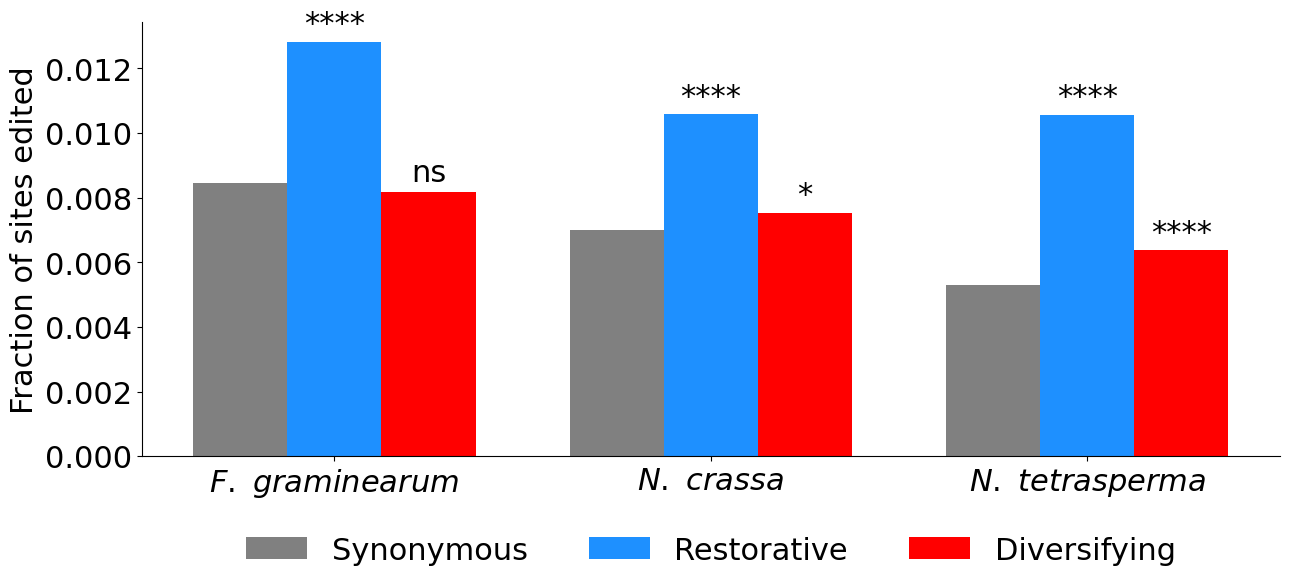

  species  Fs_weighted  Fr_weighted  Fd_weighted
0      Fg     0.008450     0.012806     0.008181
1      Nc     0.007001     0.010580     0.007524
2      Nt     0.005312     0.010573     0.006366


In [10]:
# plot fractions

species_order = ["Fg", "Nc", "Nt"]
species_labels = {
    "Fg": r"$\it{F.\ graminearum}$",
    "Nc": r"$\it{N.\ crassa}$",
    "Nt": r"$\it{N.\ tetrasperma}$",
}

def sig_symbol(p):
    if pd.isna(p): return "na"
    if p < 1e-4:   return "****"
    if p < 1e-3:   return "***"
    if p < 1e-2:   return "**"
    if p < 5e-2:   return "*"
    return "ns"

plot_df = (
    summary_df.set_index("species")
    .loc[species_order]
    .reset_index()
    .merge(chi2_results_df[["species", "p_r_vs_s", "p_d_vs_s"]], on="species", how="left")
)

plot_df["sig_r_vs_s"] = plot_df["p_r_vs_s"].apply(sig_symbol)
plot_df["sig_d_vs_s"] = plot_df["p_d_vs_s"].apply(sig_symbol)

Fs_vals = plot_df["Fs_weighted"].values.astype(float)
Fr_vals = plot_df["Fr_weighted"].values.astype(float)
Fd_vals = plot_df["Fd_weighted"].values.astype(float)

x = np.arange(len(species_order))
bar_width = 0.25
x_fs, x_fr, x_fd = x - bar_width, x, x + bar_width

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x_fs, Fs_vals, width=bar_width, color="grey",       label="Synonymous")
ax.bar(x_fr, Fr_vals, width=bar_width, color="dodgerblue", label="Restorative")
ax.bar(x_fd, Fd_vals, width=bar_width, color="red",        label="Diversifying")

ax.set_xticks(x)
ax.set_xticklabels([species_labels[s] for s in species_order], fontsize=22)
ax.set_ylabel("Fraction of sites edited", fontsize=22)
ax.tick_params(axis="y", labelsize=22)

sns.despine(ax=ax)

ax.legend(
    frameon=False,
    fontsize=22,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=3,
)

for i in range(len(species_order)):
    y_max = max(Fs_vals[i], Fr_vals[i], Fd_vals[i])
    off = 0.01 * (y_max if y_max > 0 else 1.0)

    ax.text(x_fr[i], Fr_vals[i] + off, plot_df.loc[i, "sig_r_vs_s"], ha="center", va="bottom", fontsize=22)
    ax.text(x_fd[i], Fd_vals[i] + off, plot_df.loc[i, "sig_d_vs_s"], ha="center", va="bottom", fontsize=22)

fig.tight_layout()
#fig.savefig(f"{fig_dir}/Fig3b_04292026.pdf", dpi=300, bbox_inches="tight")
plt.show()

print(summary_df[["species", "Fs_weighted", "Fr_weighted", "Fd_weighted"]])


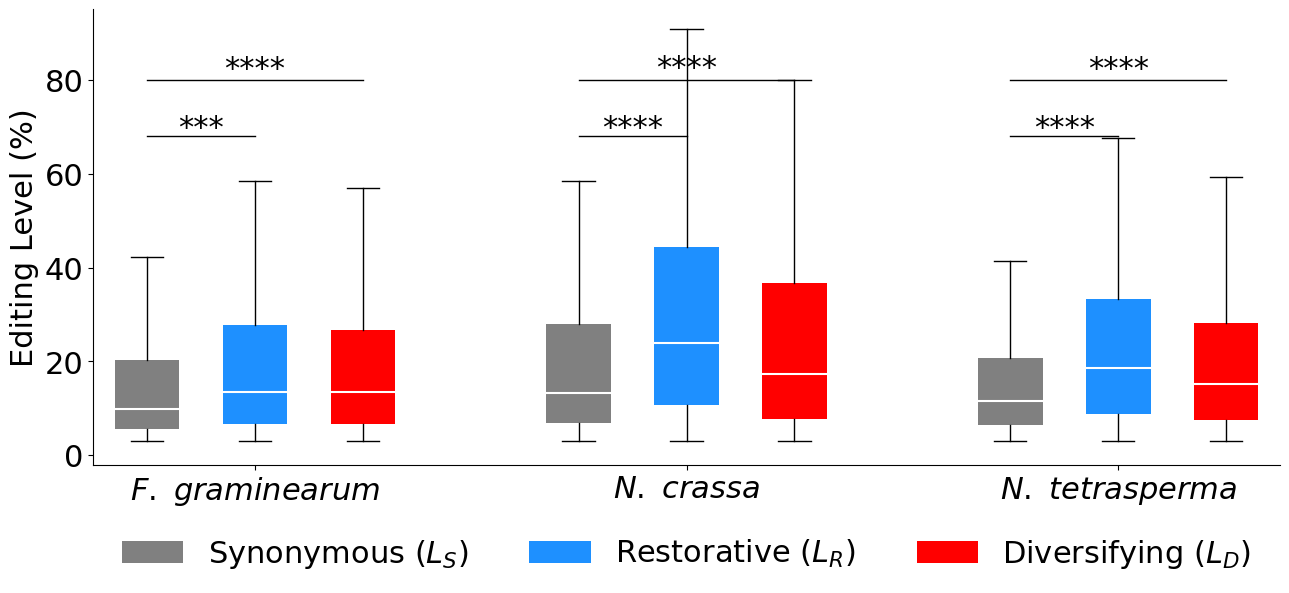

In [16]:
# editing level boxplot

def to_series(df):
    return pd.to_numeric(df["editing_level"], errors="coerce").dropna().astype(float)

editing_level_data = {
    "fg": {
        "s": to_series(fg_syn),
        "r": to_series(fg_rest),
        "d": to_series(fg_div),
    },
    "nc": {
        "s": to_series(nc_syn),
        "r": to_series(nc_rest),
        "d": to_series(nc_div),
    },
    "nt": {
        "s": to_series(nt_syn),
        "r": to_series(nt_rest),
        "d": to_series(nt_div),
    },
}

box_colors = ["grey", "dodgerblue", "red"]
edit_types = [
    r"Synonymous ($\it{L}_{S}$)",
    r"Restorative ($\it{L}_{R}$)",
    r"Diversifying ($\it{L}_{D}$)",
]

species_labels_box = {
    "fg": r"$\it{F.\ graminearum}$",
    "nc": r"$\it{N.\ crassa}$",
    "nt": r"$\it{N.\ tetrasperma}$",
}

species_order_box = ["fg", "nc", "nt"]

all_data = []
for sp in species_order_box:
    all_data.append([
        editing_level_data[sp]["s"],
        editing_level_data[sp]["r"],
        editing_level_data[sp]["d"],
    ])

fig, ax = plt.subplots(figsize=(13, 6))

positions = []
box_data = []
colors = []
xticks = []
xtick_labels = []

spacing = 4
width = 0.6

for i, (sp, (s, r, d)) in enumerate(zip(species_order_box, all_data)):
    base = i * spacing
    box_data.extend([s, r, d])
    positions.extend([base, base + 1, base + 2])
    colors.extend(box_colors)
    xticks.append(base + 1)
    xtick_labels.append(species_labels_box[sp])

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=width,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=1.5),
    showfliers=False,
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_linewidth(0)

ax.set_ylabel("Editing Level (%)", fontsize=22)
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=22)
ax.tick_params(axis="y", labelsize=22)
ax.set_ylim(-2, 95)

def get_stars(pval):
    if pval < 0.0001:
        return "****"
    elif pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

for i, (s, r, d) in enumerate(all_data):
    base = i * spacing

    if len(s) == 0 or len(r) == 0 or len(d) == 0:
        continue

    y_max = np.nanmax([s.max(), r.max(), d.max()])
    offset = 0.08 * y_max

    try:
        pval_r = mannwhitneyu(r, s, alternative="two-sided").pvalue
        stars_r = get_stars(pval_r)
        line_y = min(y_max + offset, 68)

        ax.plot([base, base + 1], [line_y, line_y], color="black", linewidth=1)
        text_y = line_y + (offset * 0.001 if stars_r != "ns" else offset * 0.2)
        ax.text(base + 0.5, text_y, stars_r, ha="center", fontsize=22)
    except Exception:
        pass

    try:
        pval_d = mannwhitneyu(d, s, alternative="two-sided").pvalue
        stars_d = get_stars(pval_d)
        line_y = min(y_max + 2 * offset, 80)

        ax.plot([base, base + 2], [line_y, line_y], color="black", linewidth=1)
        text_y = line_y + (offset * 0.08 if stars_d != "ns" else offset * 0.5)
        ax.text(base + 1, text_y, stars_d, ha="center", fontsize=22)
    except Exception:
        pass

handles = [Patch(facecolor=c, label=l) for c, l in zip(box_colors, edit_types)]

fig.tight_layout(rect=(0, 0.12, 1, 1))
sns.despine(ax=ax)

ax.legend(
    handles=handles,
    frameon=False,
    fontsize=22,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
)

#fig.savefig(f"{fig_dir}/Fig3c_04292026.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
# numbers for text

print(len(editing_level_data["fg"]["s"]), len(editing_level_data["fg"]["r"]), len(editing_level_data["fg"]["d"]))
print(len(editing_level_data["nc"]["s"]), len(editing_level_data["nc"]["r"]), len(editing_level_data["nc"]["d"]))
print(len(editing_level_data["nt"]["s"]), len(editing_level_data["nt"]["r"]), len(editing_level_data["nt"]["d"]))

summary_df


1252 259 4866
916 197 4559
772 216 4134


,species,syn_total,restorative_total,diversifying_total,motif_counts,syn_by_motif,restorative_by_motif,diversifying_by_motif,weighted_S,weighted_R,weighted_D,Fs_weighted,Fr_weighted,Fd_weighted
0,Fg,170649,17297,575245,"{'TA': 92925, 'AA': 197675, 'CA': 228967, 'GA'...","{'TA': 16923, 'AA': 56946, 'CA': 55886, 'GA': ...","{'TA': 2491, 'AA': 4824, 'CA': 6159, 'GA': 3823}","{'TA': 73511, 'AA': 135905, 'CA': 166922, 'GA'...",1237.979510,168.986725,4970.033765,0.008450,0.012806,0.008181
1,Nc,129573,17509,608327,"{'TA': 81234, 'AA': 186476, 'CA': 239038, 'GA'...","{'TA': 13691, 'AA': 51032, 'CA': 39162, 'GA': ...","{'TA': 1985, 'AA': 4362, 'CA': 6879, 'GA': 4283}","{'TA': 65558, 'AA': 131082, 'CA': 192997, 'GA'...",982.346368,139.810576,4549.843055,0.007001,0.010580,0.007524
2,Nt,143150,18954,653086,"{'TA': 87276, 'AA': 203011, 'CA': 256426, 'GA'...","{'TA': 15225, 'AA': 56551, 'CA': 43443, 'GA': ...","{'TA': 2175, 'AA': 4826, 'CA': 7319, 'GA': 4634}","{'TA': 69876, 'AA': 141634, 'CA': 205664, 'GA'...",913.202042,128.364465,4080.433493,0.005312,0.010573,0.006366
